<a href="https://colab.research.google.com/github/farrelrassya/teachingMLDL/blob/main/01.%20Machine%20Learning/08.%20Week%208/Notebook%20/%20SVM%20/%20Chapter_1_Prerequisites.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1 -- Prerequisites: Vectors, Linear Separability, and Hyperplanes

This notebook accompanies Chapter 1 of *Support Vector Machines Succinctly*. Before we can build, train, or even define a Support Vector Machine, we need fluency in three pieces of mathematical machinery that will appear in every chapter that follows:

1. **Vectors** -- the language we use to describe data points and model parameters. We will look at their magnitude, their direction, and the operation that ties two vectors together: the dot product.
2. **Linear separability** -- the geometric condition that determines whether a *linear* classifier can perfectly split a dataset. SVMs in their simplest form solve exactly this problem.
3. **Hyperplanes** -- the decision boundaries used by every linear classifier, including the SVM. We will derive their equation, learn how to use one to classify data, and see why "training a linear classifier" really means "finding a good $\mathbf{w}$".

By the end of this notebook, the equation $\mathbf{w}\cdot\mathbf{x} + b = 0$ will feel like an old friend, and the role of the weight vector $\mathbf{w}$ as the *only* thing that shapes a hyperplane will be unmistakable.


## Setup

We import the small set of libraries used throughout the chapter. `numpy` provides vector and matrix operations and a fast linear-algebra module (`numpy.linalg`); `matplotlib` is used for all plots; `math` gives us the trigonometric helpers needed for the geometric form of the dot product.


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

np.set_printoptions(precision=4, suppress=True)


## 1. Vectors

The word *vector* sits inside the name **Support Vector Machine** for a reason: every data point we ever feed into an SVM, and every parameter the SVM learns, is a vector. This first section establishes precise definitions for what a vector is, what its **magnitude** and **direction** mean, and how those two pieces uniquely determine it.


### 1.1 What is a vector?

A vector can be drawn as an arrow: a tail anchored at the origin and a tip at some point in space. In the figure below, the tip lands at $A = (4, 3)$, and we write

$$\overrightarrow{OA} = \begin{pmatrix} 4 \\ 3 \end{pmatrix}.$$

It is tempting to identify the vector *with* its coordinates, but the coordinates are only one of many ways to describe it. If you were given a blank piece of paper with a single horizontal reference line and asked to draw the same vector, you would only need two facts:

- the **length** of the arrow (its magnitude), and
- the **angle** it makes with the horizontal line (its direction).

This leads to the working definition we will use throughout the book:

> **A vector is an object that has both a magnitude and a direction.**

Coordinates are simply one convenient encoding of those two pieces of information.


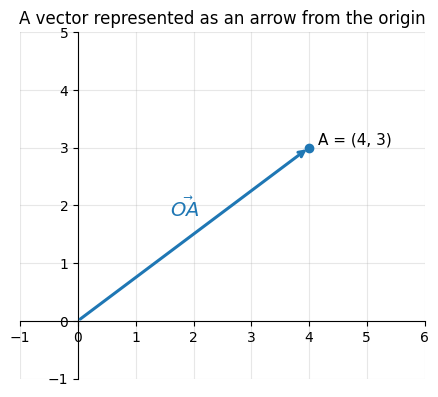

In [2]:
# Plot the vector OA = (4, 3)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.annotate('', xy=(4, 3), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='C0', lw=2.2))
ax.scatter([4], [3], color='C0', zorder=5)
ax.text(4.15, 3.05, 'A = (4, 3)', fontsize=11)
ax.text(1.6, 1.8, r'$\vec{OA}$', fontsize=14, color='C0')

# Style the axes
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.grid(alpha=0.3); ax.set_aspect('equal')
ax.set_title('A vector represented as an arrow from the origin')
plt.show()


The arrow above lives in $\mathbb{R}^2$ and is fully described by the ordered pair $(4, 3)$. We will use this vector repeatedly because it produces clean numbers: its magnitude is $5$ exactly, its direction has rational components, and it is large enough to read off a plot.

**Why this matters in practice.** Once you start working with a real dataset, every row in your feature matrix $\mathbf{X} \in \mathbb{R}^{n \times p}$ is just one of these arrows -- only living in $p$ dimensions instead of $2$. The geometry you build intuition for here transfers verbatim to the high-dimensional case; we simply lose the ability to draw it.


### 1.2 The magnitude of a vector

The **magnitude** (also called the **norm** or **length**) of a vector $\mathbf{x}$ is written $\|\mathbf{x}\|$. Geometrically it is the length of the arrow that represents the vector.

For our running example we can compute it with the **Pythagorean theorem**: the segment $OA$ is the hypotenuse of a right triangle with legs of length $4$ and $3$, so

$$\|\overrightarrow{OA}\| = \sqrt{4^2 + 3^2} = \sqrt{25} = 5.$$

In general, for an $n$-dimensional vector $\mathbf{x} = (x_1, x_2, \dots, x_n)$, the **Euclidean norm** is

$$\|\mathbf{x}\| \;=\; \sqrt{\, x_1^2 + x_2^2 + \cdots + x_n^2 \,} \;=\; \sqrt{\sum_{i=1}^{n} x_i^2}.$$


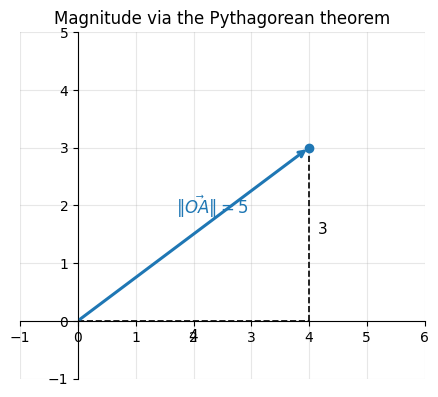

In [3]:
# Plot showing the magnitude as the hypotenuse of a right triangle
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.annotate('', xy=(4, 3), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='C0', lw=2.2))
ax.plot([0, 4], [0, 0], 'k--', lw=1.2)
ax.plot([4, 4], [0, 3], 'k--', lw=1.2)
ax.text(2, -0.35, '4', fontsize=11, ha='center')
ax.text(4.15, 1.5, '3', fontsize=11)
ax.text(1.7, 1.85, r'$\|\vec{OA}\| = 5$', fontsize=12, color='C0')
ax.scatter([4], [3], color='C0', zorder=5)

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none'); ax.spines['top'].set_color('none')
ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.grid(alpha=0.3); ax.set_aspect('equal')
ax.set_title('Magnitude via the Pythagorean theorem')
plt.show()


The plot makes the algebra visible: the dashed legs of length $4$ and $3$ are the components of the vector, and the solid arrow of length $5$ is the magnitude.

**Strategic insight.** The norm is also the scaling factor that distinguishes "the same direction" from "twice as far in that direction." When we later derive the SVM margin $\frac{2}{\|\mathbf{w}\|}$, the entire optimization problem will boil down to making the norm of $\mathbf{w}$ as small as possible -- so this seemingly trivial quantity is the central object of the SVM training problem.


In [4]:
# Compute the norm with NumPy's linalg.norm
x = [3, 4]
print(np.linalg.norm(x))


5.0


`np.linalg.norm([3, 4])` returns **`5.0`**, matching the manual computation $\sqrt{3^2 + 4^2} = \sqrt{25} = 5$.

By default, `np.linalg.norm` computes the Euclidean ($\ell_2$) norm, which is what we always mean by "magnitude" or "length" in this book. The function actually accepts a second argument `ord`: `ord=1` gives the $\ell_1$ norm $\sum_i |x_i|$, `ord=np.inf` gives $\max_i |x_i|$, and so on. These alternative norms will reappear when we discuss regularization, but the unqualified word *norm* always means $\ell_2$ here.

**A small implementation note.** Even though we passed in a Python list, NumPy returns a Python `float`. NumPy is permissive about input types: lists, tuples, and arrays are all accepted and internally promoted to an `ndarray` before the computation runs.


### 1.3 The direction of a vector

The **direction** of a non-zero vector $\mathbf{u}$ is itself a vector, defined by dividing $\mathbf{u}$ by its norm:

$$\mathbf{w} \;=\; \frac{\mathbf{u}}{\|\mathbf{u}\|} \;=\; \left( \frac{u_1}{\|\mathbf{u}\|}, \frac{u_2}{\|\mathbf{u}\|}, \dots, \frac{u_n}{\|\mathbf{u}\|} \right).$$

Why is this called the *direction*? Consider the figure below: the angle $\theta$ between $\mathbf{u}$ and the horizontal axis, and the angle $\alpha$ between $\mathbf{u}$ and the vertical axis, encode where the vector is pointing. Elementary trigonometry gives

$$\cos\theta = \frac{u_1}{\|\mathbf{u}\|}, \qquad \cos\alpha = \frac{u_2}{\|\mathbf{u}\|}.$$

These are exactly the two components of $\mathbf{w}$. Two vectors that point the same way -- regardless of their length -- share the same pair of cosines and therefore the same $\mathbf{w}$.


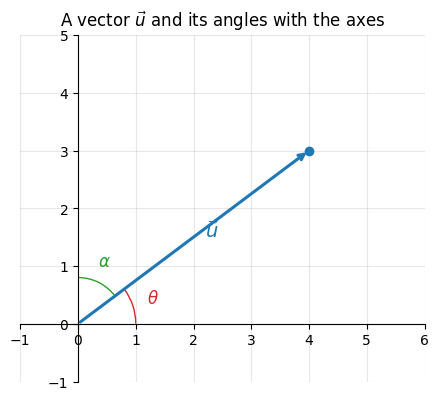

In [5]:
# A vector and its angles with the axes
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.annotate('', xy=(4, 3), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='C0', lw=2.2))

ax.add_patch(Arc((0, 0), 2, 2, angle=0, theta1=0,
                 theta2=np.degrees(np.arctan(3/4)), color='C3'))
ax.text(1.2, 0.35, r'$\theta$', fontsize=12, color='C3')

ax.add_patch(Arc((0, 0), 1.6, 1.6, angle=0,
                 theta1=np.degrees(np.arctan(3/4)), theta2=90, color='C2'))
ax.text(0.35, 1.0, r'$\alpha$', fontsize=12, color='C2')

ax.text(2.2, 1.5, r'$\vec{u}$', fontsize=14, color='C0')
ax.scatter([4], [3], color='C0', zorder=5)

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none'); ax.spines['top'].set_color('none')
ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.grid(alpha=0.3); ax.set_aspect('equal')
ax.set_title(r'A vector $\vec{u}$ and its angles with the axes')
plt.show()


The figure shows that the two angles $\theta$ (red, against the horizontal) and $\alpha$ (green, against the vertical) determine where $\mathbf{u}$ points. Their cosines are exactly the *normalized* coordinates of the vector. We can therefore re-express any vector as the product of a length and a unit-length direction:

$$\mathbf{u} \;=\; \|\mathbf{u}\| \cdot \mathbf{w}, \qquad \text{where } \|\mathbf{w}\| = 1.$$

This polar-style decomposition is the geometric reason the direction is the right thing to call $\mathbf{w}$.


In [6]:
# Compute the direction (unit vector) of a vector
def direction(x):
    return x / np.linalg.norm(x)

u = np.array([3, 4])
w = direction(u)
print(w)


[0.6 0.8]


For $\mathbf{u} = (3, 4)$ with norm $\|\mathbf{u}\| = 5$, the direction is

$$\mathbf{w} = \left(\frac{3}{5}, \frac{4}{5}\right) = (\mathbf{0.6},\, \mathbf{0.8}),$$

exactly what NumPy printed. Each component is the cosine of the angle the vector makes with one of the coordinate axes: $\cos\theta = 0.6$ corresponds to $\theta \approx 53.13^\circ$, and $\cos\alpha = 0.8$ corresponds to $\alpha \approx 36.87^\circ$. As expected, $\theta + \alpha = 90^\circ$ in two dimensions.

**Implementation note.** We pass `np.array([3, 4])` rather than a plain Python list so that the division `x / np.linalg.norm(x)` performs an *element-wise* operation. Dividing a list by a scalar would raise a `TypeError`; NumPy arrays broadcast the scalar over every element automatically.


In [7]:
# Two vectors with the same direction give the same unit vector
u_1 = np.array([3, 4])
u_2 = np.array([30, 40])
print(direction(u_1))
print(direction(u_2))


[0.6 0.8]
[0.6 0.8]


Both `u_1 = (3, 4)` and `u_2 = (30, 40)` yield the same direction vector $(\mathbf{0.6}, \mathbf{0.8})$. This is the formal confirmation that *length and direction are independent*: scaling a vector by a positive constant changes only its norm. Algebraically, if $\mathbf{u}_2 = c\,\mathbf{u}_1$ for some $c > 0$, then

$$\frac{\mathbf{u}_2}{\|\mathbf{u}_2\|} \;=\; \frac{c\,\mathbf{u}_1}{c\,\|\mathbf{u}_1\|} \;=\; \frac{\mathbf{u}_1}{\|\mathbf{u}_1\|}.$$

The factor of $c$ cancels.

**Connection to later chapters.** This invariance is precisely why an SVM's decision boundary $\mathbf{w}\cdot\mathbf{x} + b = 0$ is unchanged when we rescale $(\mathbf{w}, b)$. The hyperplane is determined by $\mathbf{w}$'s direction, not its magnitude. SVM training pins down the magnitude by an additional constraint (the margin condition) -- we will derive this in the chapter on the optimal hyperplane.


In [8]:
# Verify the norm of a unit (direction) vector is 1
print(np.linalg.norm(np.array([0.6, 0.8])))


1.0


The norm of the direction vector is exactly $\mathbf{1.0}$. We can verify this analytically:

$$\|\mathbf{w}\|^2 = 0.6^2 + 0.8^2 = 0.36 + 0.64 = 1.00.$$

Any vector with norm $1$ is called a **unit vector**. By construction, the direction of *any* non-zero vector is a unit vector, and the role of a unit vector is to encode pure directional information stripped of any magnitude.


### 1.4 Dimensions of a vector

The order in which the components of a vector are written is significant: $(3, 4)$ and $(4, 3)$ are different vectors. Formally, an $n$-dimensional vector is an ordered $n$-tuple of real numbers, and we write $\mathbf{x} \in \mathbb{R}^n$ to mean that $\mathbf{x}$ has $n$ real-valued components.

A few examples we will encounter throughout the book:

- $\mathbf{x} = (3, 4) \in \mathbb{R}^2$ is two-dimensional.
- $\mathbf{x} = (3, 4, 5) \in \mathbb{R}^3$ is three-dimensional.
- A grayscale image of $28 \times 28$ pixels flattened into a row lives in $\mathbb{R}^{784}$.
- A bag-of-words representation of a document with a $30{,}000$-word vocabulary lives in $\mathbb{R}^{30{,}000}$.

The geometric intuition we just developed for $\mathbb{R}^2$ extends *unchanged* to any $\mathbb{R}^n$: a vector still has a magnitude (an Euclidean norm computed by summing $n$ squared components), and a direction (a unit vector with $n$ entries). We simply lose the ability to draw the picture.


## 2. The dot product

The **dot product** is a scalar-valued operation between two vectors -- it takes two arrows and returns a number. Despite that simplicity, it is the single most important operation in linear classification: every prediction made by a linear model, including an SVM, is fundamentally one dot product.

We will define the dot product in two equivalent ways, geometric and algebraic, and verify on a concrete example that the two formulas agree.


### 2.1 Geometric definition

Geometrically, the dot product of two vectors $\mathbf{x}$ and $\mathbf{y}$ separated by an angle $\theta$ is

$$\mathbf{x} \cdot \mathbf{y} \;=\; \|\mathbf{x}\| \cdot \|\mathbf{y}\| \cdot \cos\theta.$$

The two norms are non-negative numbers, so the **sign and magnitude of the dot product are governed by $\cos\theta$**:

| angle $\theta$ | $\cos\theta$ | sign of $\mathbf{x}\cdot\mathbf{y}$ | interpretation |
|---|---|---|---|
| $0^\circ$ (parallel, same direction) | $+1$ | maximally positive | "fully aligned" |
| $90^\circ$ (orthogonal) | $0$ | zero | "no relationship" |
| $180^\circ$ (parallel, opposite direction) | $-1$ | maximally negative | "fully opposed" |

Keep this table in mind. When we study the **Perceptron** in the next chapter, the entire learning rule turns on whether the dot product between the weight vector and a misclassified point is positive or negative.


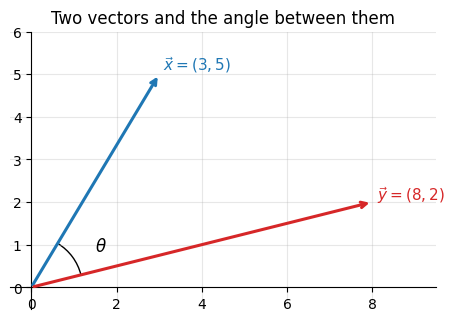

In [9]:
# Two vectors and the angle between them
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.annotate('', xy=(3, 5), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='C0', lw=2.2))
ax.annotate('', xy=(8, 2), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='C3', lw=2.2))
ax.text(3.1, 5.1, r'$\vec{x}=(3,5)$', fontsize=11, color='C0')
ax.text(8.1, 2.05, r'$\vec{y}=(8,2)$', fontsize=11, color='C3')

ax.add_patch(Arc((0, 0), 2.4, 2.4, angle=0,
                 theta1=np.degrees(np.arctan(2/8)),
                 theta2=np.degrees(np.arctan(5/3)), color='black'))
ax.text(1.5, 0.85, r'$\theta$', fontsize=12)

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none'); ax.spines['top'].set_color('none')
ax.set_xlim(-0.5, 9.5); ax.set_ylim(-0.5, 6)
ax.grid(alpha=0.3); ax.set_aspect('equal')
ax.set_title('Two vectors and the angle between them')
plt.show()


The two vectors $\mathbf{x} = (3, 5)$ and $\mathbf{y} = (8, 2)$ both lie in the first quadrant but point in noticeably different directions. The angle $\theta$ between them is exactly $45^\circ$ -- a fact we will verify numerically below.

We can also visualize how the dot product depends on this angle alone (for fixed-length vectors):


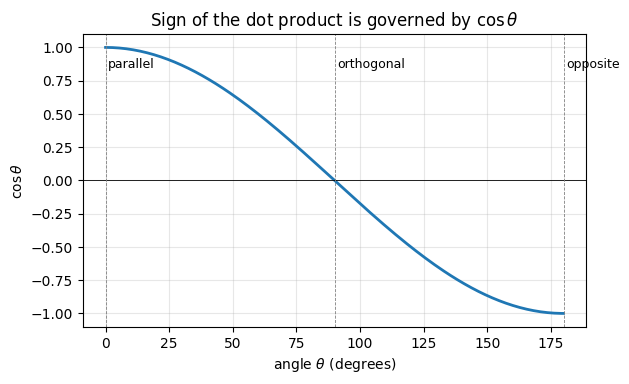

In [10]:
# Plot how cos(theta) governs the sign of the dot product
angs = np.linspace(0, 180, 200)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(angs, np.cos(np.radians(angs)), lw=2)
ax.axhline(0, color='black', lw=0.6)
for a, label in [(0, 'parallel'), (90, 'orthogonal'), (180, 'opposite')]:
    ax.axvline(a, color='gray', lw=0.6, ls='--')
    ax.text(a + 1, 0.85, label, fontsize=9)
ax.set_xlabel(r'angle $\theta$ (degrees)')
ax.set_ylabel(r'$\cos\theta$')
ax.set_title(r'Sign of the dot product is governed by $\cos\theta$')
ax.grid(alpha=0.3)
plt.show()


The curve crosses zero at $\theta = 90^\circ$, peaks at $+1$ when the vectors are parallel, and reaches $-1$ when they are antiparallel. Holding the two norms fixed, the dot product is just a rescaled version of this curve. This single picture explains why dot products show up everywhere: they answer the question *"how much does $\mathbf{x}$ point in the same direction as $\mathbf{y}$?"* with a single signed number.


In [11]:
# Geometric form of the dot product
def geometric_dot_product(x, y, theta):
    x_norm = np.linalg.norm(x)
    y_norm = np.linalg.norm(y)
    return x_norm * y_norm * math.cos(math.radians(theta))

theta = 45  # degrees
x = [3, 5]
y = [8, 2]
print(geometric_dot_product(x, y, theta))


34.00000000000001


The geometric formula returns **`34.00000000000001`** -- in exact arithmetic this is $34$. Let's verify the computation step by step:

$$\|\mathbf{x}\| = \sqrt{3^2 + 5^2} = \sqrt{34}, \qquad \|\mathbf{y}\| = \sqrt{8^2 + 2^2} = \sqrt{68}.$$

$$\mathbf{x}\cdot\mathbf{y} = \sqrt{34}\cdot\sqrt{68}\cdot\cos 45^\circ = \sqrt{34 \cdot 68}\cdot\frac{\sqrt{2}}{2} = \sqrt{2312}\cdot\frac{\sqrt{2}}{2} = \frac{\sqrt{4624}}{2} = \frac{68}{2} = 34.$$

The trailing `0.00000000000001` is **floating-point noise**: $\cos(45^\circ)$ cannot be represented exactly in binary, and the round-trip through `math.cos(math.radians(45))` introduces a relative error of about $3 \times 10^{-16}$ -- right at the edge of `float64` precision ($\approx 2.22 \times 10^{-16}$).

**Limitation of this approach.** The geometric form requires us to know $\theta$ in advance. In machine learning we never have that -- we have raw data points and need to compute their dot products directly. The algebraic form, derived next, removes the dependency on $\theta$.


### 2.2 Algebraic definition

To eliminate $\theta$ we decompose it using the angles each vector makes with the horizontal axis. Let $\beta$ be the angle of $\mathbf{x}$ above the x-axis and $\alpha$ be the angle of $\mathbf{y}$ above the x-axis. Then

$$\theta = \beta - \alpha.$$


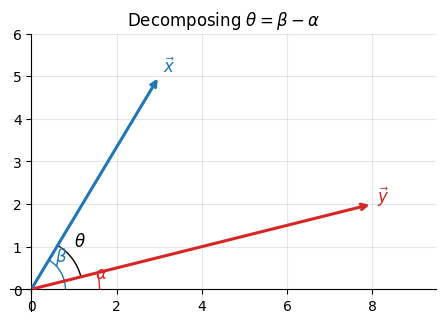

In [12]:
# Decomposing theta into beta and alpha
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.annotate('', xy=(3, 5), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='C0', lw=2.2))
ax.annotate('', xy=(8, 2), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='C3', lw=2.2))
ax.text(3.1, 5.1, r'$\vec{x}$', fontsize=12, color='C0')
ax.text(8.1, 2.05, r'$\vec{y}$', fontsize=12, color='C3')

beta_deg  = np.degrees(np.arctan(5/3))
alpha_deg = np.degrees(np.arctan(2/8))

ax.add_patch(Arc((0, 0), 1.6, 1.6, angle=0, theta1=0, theta2=beta_deg, color='C0'))
ax.text(0.55, 0.65, r'$\beta$', fontsize=12, color='C0')

ax.add_patch(Arc((0, 0), 3.2, 3.2, angle=0, theta1=0, theta2=alpha_deg, color='C3'))
ax.text(1.5, 0.25, r'$\alpha$', fontsize=12, color='C3')

ax.add_patch(Arc((0, 0), 2.4, 2.4, angle=0, theta1=alpha_deg, theta2=beta_deg, color='black'))
ax.text(1.0, 1.0, r'$\theta$', fontsize=12)

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none'); ax.spines['top'].set_color('none')
ax.set_xlim(-0.5, 9.5); ax.set_ylim(-0.5, 6)
ax.grid(alpha=0.3); ax.set_aspect('equal')
ax.set_title(r'Decomposing $\theta = \beta - \alpha$')
plt.show()


With this decomposition we can use the **cosine difference identity**:

$$\cos\theta = \cos(\beta - \alpha) = \cos\beta \cos\alpha + \sin\beta \sin\alpha.$$

Multiplying both sides by $\|\mathbf{x}\|\,\|\mathbf{y}\|$ and recognizing that

$$\|\mathbf{x}\|\cos\beta = x_1, \quad \|\mathbf{x}\|\sin\beta = x_2, \quad \|\mathbf{y}\|\cos\alpha = y_1, \quad \|\mathbf{y}\|\sin\alpha = y_2,$$

we obtain

$$\boxed{\; \mathbf{x}\cdot\mathbf{y} \;=\; x_1 y_1 + x_2 y_2 \;}$$

and in $n$ dimensions the **algebraic form** of the dot product:

$$\mathbf{x}\cdot\mathbf{y} \;=\; \sum_{i=1}^{n} x_i y_i.$$

This expression makes no reference to the angle and works directly from the components of the vectors -- exactly what we need for computational use.


In [13]:
# Algebraic form of the dot product, written by hand
def dot_product(x, y):
    result = 0
    for i in range(len(x)):
        result = result + x[i] * y[i]
    return result

x = [3, 5]
y = [8, 2]
print(dot_product(x, y))


34


The algebraic form returns **`34`** -- the same value as the geometric form, but as an exact integer. Step by step:

$$\mathbf{x}\cdot\mathbf{y} = (3)(8) + (5)(2) = 24 + 10 = 34.$$

No trigonometry, no angle, no floating-point noise. This is the form every linear-algebra library actually uses under the hood.

**Strategic insight.** The two definitions being equivalent is more than a math curiosity; it is the link between *geometry* (the world we use to build intuition) and *algebra* (the world the computer can evaluate efficiently). When we later interpret $\mathbf{w}\cdot\mathbf{x}$ as "how strongly the input $\mathbf{x}$ points along $\mathbf{w}$," we are using the geometric reading; when we *compute* it as $\sum_i w_i x_i$ in a vectorized BLAS call, we are using the algebraic reading. They are the same number.


In [14]:
# NumPy's optimized dot product
x = np.array([3, 5])
y = np.array([8, 2])
print(np.dot(x, y))


34


`np.dot(x, y)` returns **`34`**, agreeing with both the geometric and the hand-written algebraic computations. The advantages of using `np.dot` (or the `@` operator: `x @ y`) instead of a Python loop are substantial in production:

- **Speed.** NumPy delegates to a BLAS implementation (typically OpenBLAS or Intel MKL) written in optimized C/Fortran with SIMD intrinsics. A pure-Python loop is roughly $50$-$200\times$ slower for vectors of moderate size and the gap widens dramatically for matrices.
- **Memory layout.** NumPy arrays are contiguous, type-homogeneous blocks of memory. The Python `list` we used in `dot_product` is a heap-allocated array of pointers to Python `int` objects -- catastrophic for cache locality.
- **Scaling.** `np.dot` extends seamlessly to matrix-matrix products: if $\mathbf{X} \in \mathbb{R}^{n\times p}$ and $\mathbf{w} \in \mathbb{R}^p$, then `X @ w` produces all $n$ predictions in a single call.

**Cross-chapter connection.** Every linear classifier we will train in later chapters -- Perceptron, logistic regression, SVM -- ultimately reduces to evaluating $\mathbf{w}\cdot\mathbf{x} + b$ many times. Picking the right primitive here matters.


In [15]:
# Recover the angle theta from the two dot-product forms
xv = np.array([3, 5])
yv = np.array([8, 2])
cos_theta = np.dot(xv, yv) / (np.linalg.norm(xv) * np.linalg.norm(yv))
theta_deg = math.degrees(math.acos(cos_theta))
print(f"cos(theta) = {cos_theta:.6f}")
print(f"theta      = {theta_deg:.6f} degrees")


cos(theta) = 0.707107
theta      = 45.000000 degrees


Setting the two forms of the dot product equal and solving for the angle gives the **cosine similarity** formula:

$$\cos\theta \;=\; \frac{\mathbf{x}\cdot\mathbf{y}}{\|\mathbf{x}\|\,\|\mathbf{y}\|}.$$

For our example:

$$\cos\theta = \frac{34}{\sqrt{34}\cdot\sqrt{68}} = \frac{34}{\sqrt{2312}} \approx 0.707107 = \frac{\sqrt{2}}{2},$$

which gives $\theta = \mathbf{45.000000^\circ}$ -- confirming the value we used in the geometric formula above.

**Strategic insight.** This same formula is the basis of **cosine similarity** in information retrieval and embedding-based search: two documents (or two embedding vectors) are considered similar if the angle between them is small, i.e. their cosine is close to $1$. The dot product alone would unfairly favor longer vectors; dividing by the norms isolates pure directional similarity.


## 3. Linear separability

Now that we have the language of vectors and the dot product, we can ask the central geometric question of linear classification: *can the data be split into two classes by a single straight cut?* When the answer is yes, we say the data is **linearly separable**.

We motivate this with a small business case study, drawn from the chapter, and then formalize the concept across one, two, and three dimensions.


### 3.1 A motivating example: classifying wine by alcohol content

Imagine you produce two wines:

- An **expensive** wine selling at \$145 per bottle.
- A **cheap** wine selling at \$8 per bottle.

Customers have begun complaining that they receive cheap wine in expensive bottles, and the resulting reputational damage threatens the business. You suspect the two wines differ in their **alcohol by volume** (ABV) and decide to measure a sample.


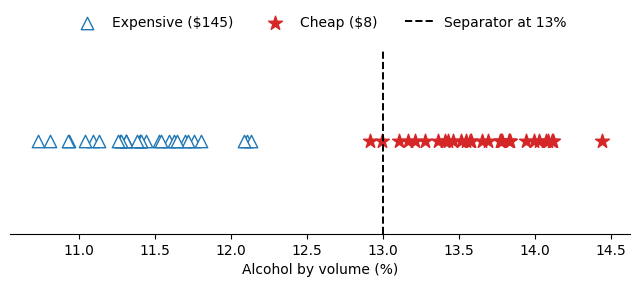

In [16]:
# A clean (textbook) version of the wine ABV measurements
np.random.seed(42)
expensive = np.random.normal(loc=11.5, scale=0.4, size=30)
cheap     = np.random.normal(loc=13.7, scale=0.4, size=30)

fig, ax = plt.subplots(figsize=(8, 2.4))
ax.scatter(expensive, np.zeros_like(expensive), marker='^', s=80,
           facecolor='white', edgecolor='C0', label='Expensive ($145)')
ax.scatter(cheap, np.zeros_like(cheap), marker='*', s=110,
           color='C3', label='Cheap ($8)')
ax.axvline(13.0, color='black', lw=1.4, ls='--', label='Separator at 13%')
ax.set_yticks([])
ax.set_xlabel('Alcohol by volume (%)')
ax.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.25), frameon=False)
ax.spines['left'].set_visible(False); ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


On this idealized data, the two classes occupy disjoint ranges of ABV: the expensive wine clusters around $11.5\%$ and the cheap wine clusters around $13.7\%$. A **single threshold** at $13\%$ perfectly separates them. Formally, the **decision rule**

$$\hat{y}(x) \;=\; \begin{cases} \text{expensive} & \text{if } x < 13\% \\ \text{cheap} & \text{if } x \geq 13\% \end{cases}$$

makes zero classification errors on this sample.

This is what *linearly separable* means in one dimension: there exists a single point that splits the real line into two half-lines, with one class entirely in each half.

**Production framing.** Once you ship this rule onto the bottling line, it solves the business problem: any bottle measured below $13\%$ ABV that was about to be labeled as cheap, or any bottle above $13\%$ that was about to be labeled as expensive, triggers a manual inspection. The model is interpretable, auditable, and trivially fast at inference -- exactly what you want for a production quality-control system.


### 3.2 Reality check: the same data when measured in the wild

The textbook example above was constructed to be cleanly separable. Real wine data does not look like that. The plot below uses overlapping distributions that more accurately reflect what an actual measurement campaign would produce:


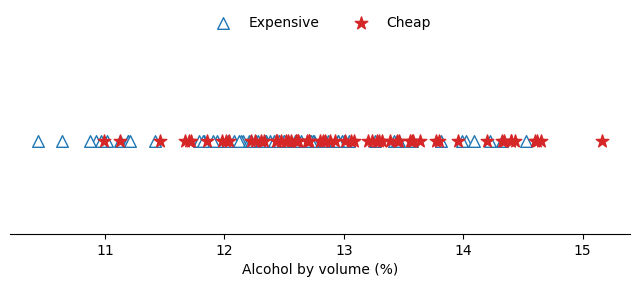

In [17]:
# A more realistic version: overlapping distributions
np.random.seed(7)
expensive = np.random.normal(loc=12.5, scale=0.9, size=60)
cheap     = np.random.normal(loc=12.9, scale=1.0, size=60)

fig, ax = plt.subplots(figsize=(8, 2.4))
ax.scatter(expensive, np.zeros_like(expensive), marker='^', s=70,
           facecolor='white', edgecolor='C0', label='Expensive')
ax.scatter(cheap, np.zeros_like(cheap), marker='*', s=90,
           color='C3', label='Cheap')
ax.set_yticks([])
ax.set_xlabel('Alcohol by volume (%)')
ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.25), frameon=False)
ax.spines['left'].set_visible(False); ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


The two distributions now overlap heavily across the $11.5\%$-$14\%$ region. **No single threshold can perfectly separate the two classes** -- whatever cutoff you choose, you will misclassify some expensive bottles as cheap and vice versa. This data is **non-linearly separable** in one dimension.

This is the rule, not the exception. Real data is rarely linearly separable in its raw form, which is why a substantial portion of the SVM literature is dedicated to two strategies for handling the non-separable case:

1. **Soft margin** -- allow some points to violate the separation constraint, paying a penalty for each violation. We will study this in detail later.
2. **Kernel methods** -- map the data into a higher-dimensional feature space where it *is* linearly separable, then solve the easy problem there.

For now, our intuition is built around the separable case, because every algorithm we derive starts from that simpler setting and is then extended to handle real data.


### 3.3 Linear separability in higher dimensions

The notion of linear separability generalizes naturally as we add features:

| dimension | separator | object that does the separating |
|---|---|---|
| $\mathbb{R}^1$ | a **point** | $0$-dimensional |
| $\mathbb{R}^2$ | a **line** | $1$-dimensional |
| $\mathbb{R}^3$ | a **plane** | $2$-dimensional |
| $\mathbb{R}^p$ for $p \geq 4$ | a **hyperplane** | $(p-1)$-dimensional |

In every case, the separator is a flat object of one dimension less than the ambient space. We will visualize the 2D case below; the 3D case is shown in the textbook with planes; for $p \geq 4$ we rely on the algebra alone.


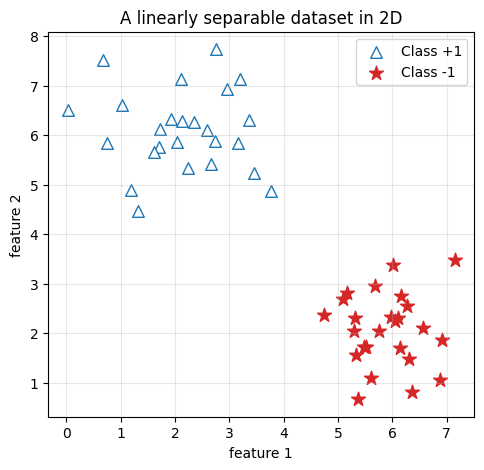

In [18]:
# A linearly separable dataset in 2D
np.random.seed(0)
class_pos = np.random.multivariate_normal([2, 6], [[0.6, 0], [0, 0.6]], 25)
class_neg = np.random.multivariate_normal([6, 2], [[0.6, 0], [0, 0.6]], 25)

fig, ax = plt.subplots(figsize=(5.5, 5.0))
ax.scatter(class_pos[:, 0], class_pos[:, 1], marker='^', s=70,
           facecolor='white', edgecolor='C0', label='Class +1')
ax.scatter(class_neg[:, 0], class_neg[:, 1], marker='*', s=110,
           color='C3', label='Class -1')
ax.set_xlabel('feature 1'); ax.set_ylabel('feature 2')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('A linearly separable dataset in 2D')
plt.show()


The two clusters are well-separated: class $+1$ sits in the top-left near $(2, 6)$ and class $-1$ sits in the bottom-right near $(6, 2)$. We can draw infinitely many straight lines that separate them perfectly -- any line passing through the gap between the clusters works.

**This non-uniqueness is the central problem an SVM solves.** The Perceptron will return *some* separating line (whichever one it finds first); the SVM will return *the* line that maximizes the gap to the nearest points -- the **maximum-margin hyperplane**. We will see in later chapters why that particular choice generalizes best to unseen data.


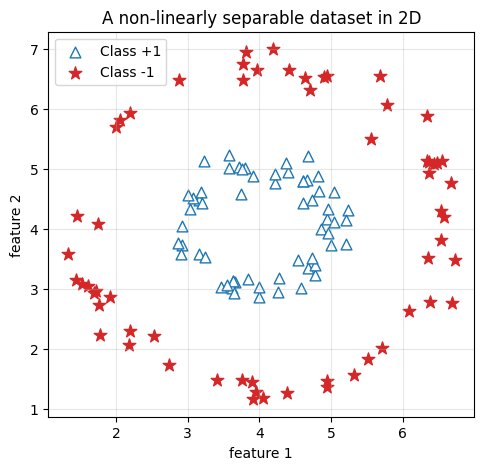

In [19]:
# A non-linearly separable dataset in 2D: concentric clusters
np.random.seed(1)
n = 60
theta_in  = np.random.uniform(0, 2*np.pi, n)
r_in      = np.random.normal(1.0, 0.18, n)
inner     = np.column_stack([r_in*np.cos(theta_in) + 4, r_in*np.sin(theta_in) + 4])

theta_out = np.random.uniform(0, 2*np.pi, n)
r_out     = np.random.normal(2.6, 0.18, n)
outer     = np.column_stack([r_out*np.cos(theta_out) + 4, r_out*np.sin(theta_out) + 4])

fig, ax = plt.subplots(figsize=(5.5, 5.0))
ax.scatter(inner[:, 0], inner[:, 1], marker='^', s=60,
           facecolor='white', edgecolor='C0', label='Class +1')
ax.scatter(outer[:, 0], outer[:, 1], marker='*', s=90,
           color='C3', label='Class -1')
ax.set_xlabel('feature 1'); ax.set_ylabel('feature 2')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('A non-linearly separable dataset in 2D')
plt.show()


These two classes form a classic *concentric rings* configuration. **No straight line can separate them** -- any line cuts the outer ring into two arcs, leaving inner-class points on both sides.

This is the prototypical example used to motivate **kernel methods** later in the book. If we apply the feature transformation

$$\phi(\mathbf{x}) = \bigl(\, x_1,\; x_2,\; x_1^2 + x_2^2\, \bigr)$$

the inner ring (small radius) and outer ring (large radius) acquire very different values along the new third dimension, and a flat plane *can* separate them. The dot product in the original space is replaced by a kernel function $K(\mathbf{x}, \mathbf{x}') = \phi(\mathbf{x}) \cdot \phi(\mathbf{x}')$, and the rest of the SVM machinery proceeds unchanged. We are not yet at that point, but the picture above is the puzzle that kernels solve.


## 4. Hyperplanes

We now reach the geometric object that powers every linear classifier: the **hyperplane**. A hyperplane is the high-dimensional generalization of a line (2D) or a plane (3D). The clean formal definition is:

> A **hyperplane** is a subspace whose dimension is one less than that of the ambient space.

In $\mathbb{R}^p$, a hyperplane is therefore a flat $(p-1)$-dimensional object that splits the space into two half-spaces. Linear classifiers use that split to assign one class to each half.


### 4.1 From a line to a hyperplane equation

Recall the equation of a line from school: $y = ax + b$, where $a$ is the slope and $b$ is the y-intercept. Although we usually think of $y$ as a function of $x$, this equation has *two* variables. Renaming $x \to x_1$ and $y \to x_2$ and rearranging:

$$ax_1 - x_2 + b = 0.$$

Define $\mathbf{w} = (a, -1)$ and $\mathbf{x} = (x_1, x_2)$. Then $\mathbf{w}\cdot\mathbf{x} = ax_1 - x_2$, and the line equation becomes

$$\boxed{\; \mathbf{w}\cdot\mathbf{x} + b = 0. \;}$$

This vector form has a striking property: **it works in any number of dimensions**. We derived it from a 2D picture, but the same equation in $\mathbb{R}^p$ defines a hyperplane. From this equation we read off two facts simultaneously:

- A hyperplane is the **set of points** $\mathbf{x} \in \mathbb{R}^p$ satisfying $\mathbf{w}\cdot\mathbf{x} + b = 0$.
- The vector $\mathbf{w}$ is **normal** (perpendicular) to that set: it points in the direction in which $\mathbf{w}\cdot\mathbf{x}$ changes fastest.

A line, a plane, and a point are all hyperplanes -- in $\mathbb{R}^2$, $\mathbb{R}^3$, and $\mathbb{R}^1$ respectively. The same equation describes all of them.


### 4.2 Recovering the line equation from the hyperplane form

We can reverse the derivation to verify consistency. Starting from $\mathbf{w}\cdot\mathbf{x} + b = 0$ in $\mathbb{R}^2$ with $\mathbf{w} = (w_1, w_2)$ and $\mathbf{x} = (x_1, x_2)$:

$$w_1 x_1 + w_2 x_2 + b = 0 \quad\Longrightarrow\quad x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}.$$

Comparing with $x_2 = a x_1 + c$ we identify

$$a = -\frac{w_1}{w_2}, \qquad c = -\frac{b}{w_2}.$$

A few important consequences:

- The y-intercept of the line is $-b/w_2$, **not** $b$. The bias term $b$ in the hyperplane equation is *not* the same as the intercept of the line, even though they both got the letter "$b$" historically. The two are equal only when $w_2 = -1$.
- If $w_1$ and $w_2$ have the same sign, the slope $-w_1/w_2$ is **negative**.
- Multiplying $(\mathbf{w}, b)$ by any nonzero scalar yields the same hyperplane: $(\mathbf{w}\cdot\mathbf{x} + b = 0) \Leftrightarrow (c\mathbf{w}\cdot\mathbf{x} + cb = 0)$. The hyperplane is determined up to scale.


### 4.3 Classifying data with a hyperplane

Once we have a hyperplane, classification is purely geometric: a point is assigned a label based on **which side of the hyperplane it sits on**. We define the **hypothesis function**

$$h(\mathbf{x}) \;=\; \operatorname{sign}\bigl(\,\mathbf{w}\cdot\mathbf{x} + b\,\bigr) \;=\; \begin{cases} +1 & \text{if } \mathbf{w}\cdot\mathbf{x} + b > 0 \\ -1 & \text{if } \mathbf{w}\cdot\mathbf{x} + b < 0. \end{cases}$$

Because the right-hand side is a linear combination of the components of $\mathbf{x}$, $h$ is called a **linear classifier**. The plot below illustrates this with the same separable dataset and a specific hyperplane defined by $\mathbf{w} = (2, 1)$ and $b = -5$.


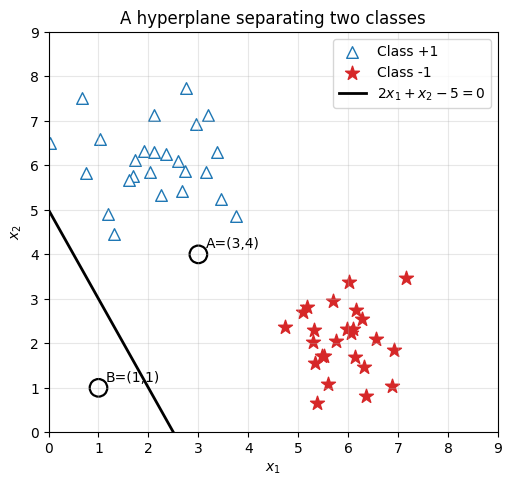

In [20]:
# Visualize a hyperplane (line) separating the two classes
np.random.seed(0)
class_pos = np.random.multivariate_normal([2, 6], [[0.6, 0], [0, 0.6]], 25)
class_neg = np.random.multivariate_normal([6, 2], [[0.6, 0], [0, 0.6]], 25)

fig, ax = plt.subplots(figsize=(5.8, 5.2))
ax.scatter(class_pos[:, 0], class_pos[:, 1], marker='^', s=70,
           facecolor='white', edgecolor='C0', label='Class +1')
ax.scatter(class_neg[:, 0], class_neg[:, 1], marker='*', s=110,
           color='C3', label='Class -1')

xs = np.linspace(0, 9, 100)
# The hyperplane 2*x1 + x2 - 5 = 0  =>  x2 = -2*x1 + 5
ax.plot(xs, -2 * xs + 5, 'k-', lw=2, label=r'$2x_1 + x_2 - 5 = 0$')

# Highlight test points A and B
ax.scatter([3], [4], marker='o', s=160, facecolor='none', edgecolor='black', lw=1.6)
ax.text(3.15, 4.15, 'A=(3,4)', fontsize=10)
ax.scatter([1], [1], marker='o', s=160, facecolor='none', edgecolor='black', lw=1.6)
ax.text(1.15, 1.15, 'B=(1,1)', fontsize=10)

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_xlim(0, 9); ax.set_ylim(0, 9)
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
ax.set_title('A hyperplane separating two classes')
plt.show()


The line $2x_1 + x_2 - 5 = 0$ -- equivalently $x_2 = -2x_1 + 5$ -- separates the two classes cleanly. We have circled two test points so we can verify the hypothesis function on them numerically: $A = (3, 4)$ visibly lies *above* the line, and $B = (1, 1)$ lies *below* it. Geometrically these correspond to the two half-planes defined by $\mathbf{w}\cdot\mathbf{x} + b > 0$ and $\mathbf{w}\cdot\mathbf{x} + b < 0$.


In [21]:
# Apply the hypothesis function h(x) = sign(w . x + b) to two test points
w = np.array([2, 1])
b = -5

def h(x_vec, w_vec, b_val):
    return np.sign(np.dot(w_vec, x_vec) + b_val)

A = np.array([3, 4])
B = np.array([1, 1])
print(f"For x=A={A}: w.x + b = {np.dot(w, A) + b}, h(x) = {int(h(A, w, b))}")
print(f"For x=B={B}: w.x + b = {np.dot(w, B) + b}, h(x) = {int(h(B, w, b))}")


For x=A=[3 4]: w.x + b = 5, h(x) = 1
For x=B=[1 1]: w.x + b = -2, h(x) = -1


For the two points we get:

- $\mathbf{x} = A = (3, 4)$: $\mathbf{w}\cdot\mathbf{x} + b = (2)(3) + (1)(4) - 5 = \mathbf{5}$, so $h(A) = +1$. Point $A$ is on the *positive* side of the hyperplane.
- $\mathbf{x} = B = (1, 1)$: $\mathbf{w}\cdot\mathbf{x} + b = (2)(1) + (1)(1) - 5 = \mathbf{-2}$, so $h(B) = -1$. Point $B$ is on the *negative* side.

Both predictions agree with what we see in the plot: $A$ sits with the upper cluster, $B$ sits with the lower cluster.

**Interpretation of the magnitude.** Although $h$ only uses the *sign* of $\mathbf{w}\cdot\mathbf{x} + b$, the magnitude is meaningful too. It is proportional to the **distance from the point to the hyperplane**:

$$\text{distance}(\mathbf{x}, \text{hyperplane}) \;=\; \frac{|\mathbf{w}\cdot\mathbf{x} + b|}{\|\mathbf{w}\|}.$$

For our two points: $\|\mathbf{w}\| = \sqrt{2^2 + 1^2} = \sqrt{5} \approx 2.236$, so $A$ is roughly $5/\sqrt{5} = \sqrt{5} \approx 2.24$ units from the line, and $B$ is roughly $2/\sqrt{5} \approx 0.89$ units from the line. The Support Vector Machine will exploit exactly this geometric distance when it defines the **margin** -- the larger this quantity is for the closest training point, the more confident (and, it turns out, the more generalizable) the classifier becomes.


### 4.4 Augmented vectors -- folding $b$ into $\mathbf{w}$

Carrying the bias term $b$ separately is notationally clumsy. We can absorb it into the weight vector by augmenting both $\mathbf{x}$ and $\mathbf{w}$ with one extra coordinate:

$$\hat{\mathbf{x}} = \begin{pmatrix} 1 \\ x_1 \\ x_2 \\ \vdots \\ x_n \end{pmatrix}, \qquad \hat{\mathbf{w}} = \begin{pmatrix} b \\ w_1 \\ w_2 \\ \vdots \\ w_n \end{pmatrix}.$$

Their dot product is

$$\hat{\mathbf{w}} \cdot \hat{\mathbf{x}} \;=\; b\cdot 1 + w_1 x_1 + w_2 x_2 + \cdots + w_n x_n \;=\; \mathbf{w}\cdot\mathbf{x} + b,$$

so the hypothesis function simplifies to

$$h(\hat{\mathbf{x}}) \;=\; \operatorname{sign}\bigl(\hat{\mathbf{w}} \cdot \hat{\mathbf{x}}\bigr).$$

This is the form we will use whenever we want to keep the algebra clean -- the bias is no longer special, it is just one more weight associated with a constant feature equal to $1$.


In [22]:
# The same prediction using the augmented form
x_hat = np.array([1, 3, 4])      # leading 1 absorbs b
w_hat = np.array([-5, 2, 1])     # b = -5 in the leading position

print(f"x_hat = {x_hat}")
print(f"w_hat = {w_hat}")
print(f"w_hat . x_hat = {np.dot(w_hat, x_hat)}")
print(f"sign = {int(np.sign(np.dot(w_hat, x_hat)))}")


x_hat = [1 3 4]
w_hat = [-5  2  1]
w_hat . x_hat = 5
sign = 1


The augmented dot product $\hat{\mathbf{w}}\cdot\hat{\mathbf{x}} = \mathbf{5}$ matches the value $\mathbf{w}\cdot\mathbf{x} + b = 5$ from the previous cell exactly, and the predicted sign $\mathbf{+1}$ is identical. The augmentation is a notational rewrite -- not an algorithmic change.

**Why this rewrite matters.** Most theoretical treatments of linear classifiers (Perceptron, SVM, logistic regression) are presented in the augmented form because every formula gets shorter and every proof gets cleaner. Practical libraries like `scikit-learn` keep the bias separate (the `intercept_` attribute) for clarity and numerical stability when features are not centered, but the underlying mathematics is the same.


### 4.5 The hyperplane is determined by $\mathbf{w}$ alone

Working in augmented form, the hyperplane equation is simply

$$\hat{\mathbf{w}} \cdot \hat{\mathbf{x}} = 0,$$

and the *only* thing that controls its shape is the augmented weight vector $\hat{\mathbf{w}}$. Each different $\hat{\mathbf{w}}$ produces a different hyperplane. The plot below shows four hyperplanes corresponding to four different choices of $\hat{\mathbf{w}}$.


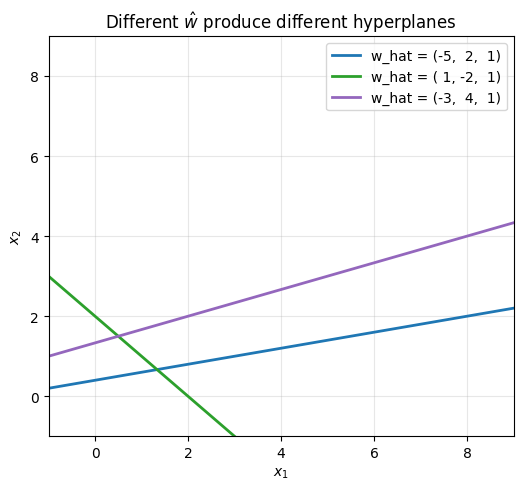

In [23]:
# Different w produce different hyperplanes
fig, ax = plt.subplots(figsize=(6.0, 5.2))
xs = np.linspace(-1, 9, 100)

configs = [
    (np.array([2,  1, -5]), 'w_hat = (-5,  2,  1)', 'C0'),
    (np.array([1, -1,  0]), 'w_hat = ( 0,  1, -1)', 'C3'),
    (np.array([-2, 1,  1]), 'w_hat = ( 1, -2,  1)', 'C2'),
    (np.array([4,  1, -3]), 'w_hat = (-3,  4,  1)', 'C4'),
]
# w_aug here is stored as (b, w1, w2). For plotting we solve w1*x + w2*y + b = 0.
for w_aug, lab, c in configs:
    b, w1, w2 = w_aug
    if w2 != 0:
        ax.plot(xs, -(w1 * xs + b) / w2, lw=2, label=lab, color=c)

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_xlim(-1, 9); ax.set_ylim(-1, 9)
ax.legend(); ax.grid(alpha=0.3)
ax.set_title(r'Different $\hat{w}$ produce different hyperplanes')
plt.show()


Each line in the plot corresponds to one specific augmented weight vector. They differ in slope, intercept, and orientation -- yet all are produced by the same equation $\hat{\mathbf{w}}\cdot\hat{\mathbf{x}} = 0$, with only $\hat{\mathbf{w}}$ changing.

This observation crystallizes the role of a learning algorithm:

> **Training a linear classifier means finding a single vector $\hat{\mathbf{w}}$.**

Every linear-classification algorithm we will study reduces to a search procedure over $\hat{\mathbf{w}}$:

- The **Perceptron** updates $\hat{\mathbf{w}}$ one mistake at a time until it finds *any* separating hyperplane.
- **Logistic regression** finds the $\hat{\mathbf{w}}$ that maximizes the log-likelihood of the labels.
- The **Support Vector Machine** finds the $\hat{\mathbf{w}}$ that maximizes the margin (the gap to the nearest training points), subject to the separation constraints.

Same problem, different objective functions. That is the unifying perspective the rest of this book is built on.

**Cross-chapter preview.** In the chapter on the SVM optimization problem, we will see that maximizing the margin is equivalent to *minimizing* $\|\mathbf{w}\|$ subject to the constraint $y_i(\mathbf{w}\cdot\mathbf{x}_i + b) \geq 1$ for every training point. The norm of $\mathbf{w}$, which we computed back in Section 1.2 with `np.linalg.norm`, is therefore literally the quantity the SVM tries to make small. Every concept introduced in this chapter has a direct, mechanical role in the algorithm we are about to build.


## 5. Summary

This chapter built the foundational vocabulary the rest of the book relies on. The three big ideas:

**Vectors.** A vector is an object with a magnitude $\|\mathbf{x}\|$ (computed by the Euclidean norm $\sqrt{\sum_i x_i^2}$) and a direction (the unit vector $\mathbf{x}/\|\mathbf{x}\|$). These two pieces decompose any vector as $\mathbf{x} = \|\mathbf{x}\| \cdot \mathbf{w}$ with $\|\mathbf{w}\| = 1$. We use NumPy arrays and `np.linalg.norm` to compute these efficiently.

**The dot product.** The dot product $\mathbf{x}\cdot\mathbf{y}$ has two equivalent forms -- the geometric form $\|\mathbf{x}\|\,\|\mathbf{y}\|\cos\theta$ that builds intuition, and the algebraic form $\sum_i x_i y_i$ that the computer evaluates. The two together give us the **cosine similarity** formula and the central operation of every linear model.

**Linear separability and hyperplanes.** Data is linearly separable when a flat object -- a point in 1D, a line in 2D, a plane in 3D, a hyperplane in higher dimensions -- can split the two classes perfectly. Every such separator obeys the same equation,

$$\mathbf{w}\cdot\mathbf{x} + b = 0 \qquad \Longleftrightarrow \qquad \hat{\mathbf{w}}\cdot\hat{\mathbf{x}} = 0,$$

and the corresponding linear classifier predicts $h(\mathbf{x}) = \operatorname{sign}(\mathbf{w}\cdot\mathbf{x} + b)$. The shape of the decision boundary is controlled entirely by $\mathbf{w}$, so every linear-classification algorithm -- Perceptron, logistic regression, SVM -- is a different recipe for choosing $\mathbf{w}$.

**What's next.** In the next chapter we study the simplest such recipe: the **Perceptron learning algorithm**, which finds a separating $\mathbf{w}$ by iterative, mistake-driven updates. After that we will see why the Perceptron's choice of $\mathbf{w}$ is unsatisfying -- it returns *some* separating hyperplane but not the *best* one -- and how the Support Vector Machine fixes that by maximizing the margin.
